# Does reasoning effort actually help? (UiPad vision QA)

A **severely minimal** UiPad eval. Pipeline, in order:

1. **Sweep** — run **Kimi K3** (Fireworks, open) and closed frontier models (**Claude Opus 4.8**, **GPT-5.6 Sol**, **GPT-5.5**) across each model's **reasoning-effort ladder**; store the raw model output.
2. **Extract** — a separate LLM (**Muse Glimmer on Fireworks**) pulls the final answer out of each raw response using **structured outputs** (JSON schema). The extracted answer is stored.
3. **Judge programmatically** — compare the *extracted* answer to gold with plain deterministic rules (number ±1%, yes/no, string equality, coordinates IoU ≥ 0.5). **No LLM decides correctness.**
4. **Graphs** — three views only.

The extractor LLM never judges; it only normalizes free-text into a typed value, so nobody can call the scoring a brittle-regex artifact *or* an opaque LLM-judge. Everything is one resumable file (`uipad_results.jsonl`), graded inline in a single pass — runs end to end top-to-bottom.

The headline metric is **pass@1** — the chance a single response is correct (mean single-sample success over `N_SAMPLES` draws). It's the conservative, standard choice: no best-of-k inflation. The `N_SAMPLES` draws only tighten the error bars.

The three charts:
1. **Cost per successful task vs pass@1** (per model)
2. **Reasoning spend vs pass@1** (per model)
3. **Efficiency frontier** across all models

The point: **more reasoning effort does not buy meaningfully better pass@1 on this task.**

**Prereqs:** `FIREWORKS_API_KEY` (and optionally `OPENAI_API_KEY`, `ANTHROPIC_API_KEY`) in `training/.env`; `pip install -e "../../.[eval]"`.

In [1]:
# Run once if imports fail.
import sys
!{sys.executable} -m pip install -q eval-protocol openai anthropic datasets huggingface_hub tiktoken python-dotenv matplotlib pandas numpy tqdm


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [7]:
# --- config ---
import ast
import asyncio
import base64
import json
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tiktoken
from datasets import load_dataset
from dotenv import load_dotenv
from eval_protocol.models import EvaluationRow, Message
from huggingface_hub import hf_hub_download, list_repo_files
from openai import AsyncOpenAI
from anthropic import AsyncAnthropic
from tqdm.auto import tqdm

MODELS = [
    {"label": "Kimi K3", "short": "K3", "provider": "fireworks",
     "model": "accounts/fireworks/models/kimi-k3",
     "efforts": ["none", "low", "high", "max"],
     "price_in": 3.00, "price_out": 15.00},
    {"label": "Claude Opus 4.8 (Anthropic)", "short": "Opus 4.8", "provider": "anthropic",
     "model": "claude-opus-4-8",
     "efforts": ["low", "medium", "high", "xhigh", "max"],
     "price_in": 15.00, "price_out": 75.00},
    {"label": "GPT-5.6 Sol (OpenAI)", "short": "5.6 Sol", "provider": "openai",
     "model": "gpt-5.6-sol",
     "efforts": ["none", "low", "medium", "high", "xhigh", "max"],
     "price_in": 5.00, "price_out": 30.00},
    {"label": "GPT-5.5 (OpenAI)", "short": "5.5", "provider": "openai",
     "model": "gpt-5.5",
     "efforts": ["none", "low", "medium", "high", "xhigh"],
     "price_in": 5.00, "price_out": 30.00},
]

SPLIT = "test"
MAX_ROWS = 'all'        # smoke=40; "all" for full split
N_SAMPLES = 3           # draws per question per effort
MAX_TOKENS = None
TEMPERATURE = 0.8
CONCURRENCY = 8
REQUEST_TIMEOUT = 1200

DATA_DIR = Path("data") / "uipad"
RESULTS_PATH = Path("uipad_results.jsonl")   # single resumable results file

SYSTEM = (
    "You answer questions about a macOS application screenshot. "
    "Please think first and then reply with the answer\n"
    "- counting / numeric questions -> a number (e.g. 3 or 49.99)\n"
    "- yes/no questions -> Yes or No\n"
    "- text questions -> the exact answer string\n"
    "- click-location questions -> bounding box as [(x1, y1), (x2, y2)] using pixel coordinates"
)

# Load .env from the repo root (a parent dir holding .env or requirements.txt).
repo_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / ".env").exists() or (p / "requirements.txt").exists()),
    Path.cwd(),
)
load_dotenv(repo_root / ".env")
if not os.getenv("FIREWORKS_API_KEY"):
    raise EnvironmentError(f"Set FIREWORKS_API_KEY in {repo_root / '.env'} (copy .env.example to .env)")
os.environ.setdefault("FIREWORKS_AI_API_KEY", os.environ["FIREWORKS_API_KEY"])
os.environ.setdefault("EP_LLM_API_BASE", "https://api.fireworks.ai/inference/v1")

fw_client = AsyncOpenAI(base_url="https://api.fireworks.ai/inference/v1",
                        api_key=os.environ["FIREWORKS_API_KEY"], timeout=REQUEST_TIMEOUT)
openai_client = (AsyncOpenAI(api_key=os.environ["OPENAI_API_KEY"], timeout=REQUEST_TIMEOUT)
                 if os.getenv("OPENAI_API_KEY") else None)
anthropic_client = (AsyncAnthropic(api_key=os.environ["ANTHROPIC_API_KEY"], timeout=REQUEST_TIMEOUT)
                    if os.getenv("ANTHROPIC_API_KEY") else None)

HAVE = {"fireworks": True, "openai": openai_client is not None, "anthropic": anthropic_client is not None}
ACTIVE_MODELS = [m for m in MODELS if HAVE.get(m["provider"], False)]
for _prov, _ok in HAVE.items():
    if not _ok and any(m["provider"] == _prov for m in MODELS):
        print(f"Note: no API key for {_prov} -> those models are skipped.")

_enc = tiktoken.get_encoding("cl100k_base")
assert TEMPERATURE > 0, "sampling is meaningless at temperature 0 (identical draws)"
print("models:", [m["label"] for m in ACTIVE_MODELS])
print(f"split={SPLIT} rows={MAX_ROWS} n_samples={N_SAMPLES} temperature={TEMPERATURE}")

models: ['Kimi K3', 'Claude Opus 4.8 (Anthropic)', 'GPT-5.6 Sol (OpenAI)', 'GPT-5.5 (OpenAI)']
split=test rows=all n_samples=3 temperature=0.8


In [8]:
# Build eval-protocol rows: screenshot (data-URI) + question, ground truth, answer type.
DATA_DIR.mkdir(parents=True, exist_ok=True)

repo_files = list_repo_files("macpaw-research/UiPad", repo_type="dataset")
SCREEN_PNG: dict[int, str] = {}
for path in repo_files:
    if path.startswith("app_data/") and path.endswith(".png"):
        SCREEN_PNG[int(path.split("/")[2])] = path
print(f"indexed {len(SCREEN_PNG)} screenshots")

raw = load_dataset("macpaw-research/UiPad", split=SPLIT)
_limit = None if (MAX_ROWS is None or str(MAX_ROWS).lower() == "all") else int(MAX_ROWS)
if _limit is not None:
    raw = raw.select(range(min(_limit, len(raw))))


def _local_png(screen_id: int) -> Path:
    rel = SCREEN_PNG[screen_id]
    local = DATA_DIR / rel
    if not local.exists():
        local.parent.mkdir(parents=True, exist_ok=True)
        downloaded = hf_hub_download(repo_id="macpaw-research/UiPad", repo_type="dataset",
                                     filename=rel, local_dir=DATA_DIR)
        if not local.exists():
            local = Path(downloaded)
    return local


def _data_uri(path: Path) -> str:
    b64 = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"data:image/png;base64,{b64}"


rows: list[EvaluationRow] = []
for i, ex in enumerate(tqdm(raw, desc="build rows")):
    sid = int(ex["Screen id"])
    png = _local_png(sid)
    user_content = [
        {"type": "image_url", "image_url": {"url": _data_uri(png)}},
        {"type": "text", "text": ex["Question"]},
    ]
    row = EvaluationRow(
        messages=[Message(role="system", content=SYSTEM), Message(role="user", content=user_content)],
        ground_truth=ex["Answer"],
    )
    row.input_metadata.row_id = str(i)
    row.input_metadata.dataset_info = {
        "app": ex["App name"], "screen_id": sid,
        "question": ex["Question"], "answer_type": ex["Answer Type"],
    }
    rows.append(row)

print(f"built {len(rows)} EvaluationRows from UiPad/{SPLIT}")

indexed 352 screenshots


build rows: 100%|██████████| 228/228 [00:00<00:00, 675.88it/s]

built 228 EvaluationRows from UiPad/test


In [9]:
# STEP 2 + 3: structured-output EXTRACTOR (LLM) + PROGRAMMATIC judge.
#   - The extractor (Muse Glimmer on Fireworks) turns a raw, verbose answer into a typed
#     value using structured outputs (a JSON schema per answer type). It only normalizes;
#     it never decides correctness.
#   - The judge is pure Python: it compares the extracted value to gold with deterministic
#     rules. No LLM in the scoring decision.
EXTRACTOR_MODEL = "accounts/fireworks/models/muse-glimmer-30b"
EXTRACTOR_EFFORT = "none"          # extraction is mechanical; keep it cheap + deterministic
EXTRACTOR_TEMPERATURE = 0.0
IOU_THRESHOLD = 0.5

# Per-answer-type JSON schema handed to the extractor via response_format (Fireworks:
# {"type": "json_object", "schema": <json-schema>}). "value"/"box" are nullable so the
# extractor can say "no answer present" instead of hallucinating one.
_SCHEMAS = {
    "number": {"type": "object", "properties": {"value": {"type": ["number", "null"]}},
               "required": ["value"], "additionalProperties": False},
    "yes/no": {"type": "object", "properties": {"value": {"type": ["string", "null"],
               "enum": ["yes", "no", None]}}, "required": ["value"], "additionalProperties": False},
    "string": {"type": "object", "properties": {"value": {"type": ["string", "null"]}},
               "required": ["value"], "additionalProperties": False},
    "coordinates": {"type": "object", "properties": {"box": {
        "type": ["array", "null"],
        "items": {"type": "array", "items": {"type": "number"}, "minItems": 2, "maxItems": 2},
        "minItems": 2, "maxItems": 2}}, "required": ["box"], "additionalProperties": False},
}
_TYPE_ALIAS = {"yes-no": "yes/no", "text": "string"}


def _schema_for(answer_type: str):
    at = _TYPE_ALIAS.get((answer_type or "").lower(), (answer_type or "").lower())
    return at, _SCHEMAS.get(at)


_EXTRACT_SYS = (
    "You extract the final answer from a model's response to a screenshot question. "
    "The response may contain reasoning, <think> blocks, prose, or restatements -- ignore "
    "all of that and return only the answer, matching the provided JSON schema exactly. "
    "For numbers, return the numeric value only. For yes/no, return 'yes' or 'no'. For "
    "strings, return the exact answer string. For coordinates, return the click bounding "
    "box as [[x1, y1], [x2, y2]] in pixel coordinates. If no answer is present, use null."
)


async def extract_answer(answer_type: str, question: str, pred: str) -> dict:
    at, schema = _schema_for(answer_type)
    if schema is None:
        return {"value": None}
    user = f"QUESTION: {question}\nANSWER TYPE: {answer_type}\nMODEL RESPONSE:\n{pred}"
    resp = await fw_client.chat.completions.create(
        model=EXTRACTOR_MODEL,
        messages=[{"role": "system", "content": _EXTRACT_SYS}, {"role": "user", "content": user}],
        response_format={"type": "json_object", "schema": schema},
        temperature=EXTRACTOR_TEMPERATURE, reasoning_effort=EXTRACTOR_EFFORT, max_tokens=2048,
    )
    key = "box" if at == "coordinates" else "value"
    raw = resp.choices[0].message.content or ""
    try:
        obj = json.loads(raw)
    except Exception:
        obj = None
    # Normalize whatever the extractor returned into {"value"/"box": ...}:
    #   - proper object -> use as-is
    #   - bare JSON scalar/list (e.g. 3 or [[..],[..]]) -> wrap
    #   - non-JSON raw text (e.g. yes) -> use the cleaned text (ast for coords)
    if isinstance(obj, dict):
        return obj
    if obj is not None:
        return {key: obj}
    txt = raw.strip()
    if at == "coordinates":
        try:
            return {"box": ast.literal_eval(txt)}
        except Exception:
            return {"box": None}
    return {"value": txt if txt else None}


# ---- deterministic gold parsers (no LLM) ----
def _gold_number(gold):
    try:
        return float(str(gold).strip().replace(",", ""))
    except Exception:
        return None


def _yn(s):
    s = str(s).strip().lower()
    return "yes" if s.startswith("y") else ("no" if s.startswith("n") else None)


def _as_box(val):
    try:
        if val is None:
            return None
        if len(val) == 2 and all(hasattr(p, "__len__") and len(p) == 2 for p in val):
            (x1, y1), (x2, y2) = val
        elif len(val) == 4:
            x1, y1, x2, y2 = val
        else:
            return None
        x1, y1, x2, y2 = float(x1), float(y1), float(x2), float(y2)
        return min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2)
    except Exception:
        return None


def _gold_box(gold):
    try:
        return _as_box(ast.literal_eval(str(gold).strip()))
    except Exception:
        return None


def _iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    if inter == 0:
        return 0.0
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    denom = area_a + area_b - inter
    return inter / denom if denom > 0 else 0.0


def judge_extracted(extracted: dict, gold, answer_type: str) -> tuple[float, str]:
    """Pure-Python comparison of the extracted answer against gold. No LLM here."""
    at, _ = _schema_for(answer_type)
    if at == "number":
        p = extracted.get("value")
        g = _gold_number(gold)
        if g is None:
            return 0.0, "bad gold number"
        if p is None:
            return 0.0, "no number extracted"
        ok = abs(float(p) - g) <= max(0.01, abs(g) * 0.01)
        return (1.0 if ok else 0.0), f"number ext={p} gold={g}"
    if at == "yes/no":
        p, g = _yn(extracted.get("value")), _yn(gold)
        ok = p is not None and p == g
        return (1.0 if ok else 0.0), f"yes/no ext={p} gold={g}"
    if at == "coordinates":
        pb, gb = _as_box(extracted.get("box")), _gold_box(gold)
        if gb is None:
            return 0.0, "bad gold box"
        if pb is None:
            return 0.0, "no box extracted"
        iou = _iou(pb, gb)
        return (1.0 if iou >= IOU_THRESHOLD else 0.0), f"iou={iou:.2f}"
    p = extracted.get("value")
    if p is None:
        return 0.0, "no string extracted"
    ok = str(p).strip().lower() == str(gold).strip().lower()
    return (1.0 if ok else 0.0), f"string ext={p!r} gold={str(gold)!r}"


print(f"extractor ready: {EXTRACTOR_MODEL} (structured outputs) + programmatic judge (coords IoU>={IOU_THRESHOLD})")

extractor ready: accounts/fireworks/models/muse-glimmer-30b (structured outputs) + programmatic judge (coords IoU>=0.5)


In [10]:
# STEP 1: rollout (reasoning sweep) with resume, then inline STEP 2 (extract) + STEP 3 (judge).
# Each sample: call model -> extractor LLM (structured) -> deterministic compare. One record
# per (model, effort, question, sample), storing raw pred, the extracted answer, and the
# programmatic score. Appended the moment it finishes (Ctrl-C safe; re-run resumes).
import threading


def _record_key(model_label, effort, row_id, sample_idx):
    return (model_label, effort, str(row_id), int(sample_idx))


def load_existing_results(path):
    if not path.exists():
        return {}
    out, dropped_err = {}, 0
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if rec.get("error"):
                dropped_err += 1
                continue
            out[_record_key(rec["model"], rec["effort"], rec["row_id"], rec["sample_idx"])] = rec
    if dropped_err:
        print(f"resume: {dropped_err} errored record(s) will be retried")
    return out


def _estimate_reasoning_tokens(text):
    return len(_enc.encode(text or ""))


def _cost_usd(ptok, ctok, price_in, price_out):
    return (ptok * price_in + ctok * price_out) / 1_000_000


def _split_row(row):
    system = next((m.content for m in row.messages if m.role == "system"), "")
    user = next((m.content for m in row.messages if m.role == "user"), [])
    b64, question = "", ""
    for part in (user if isinstance(user, list) else []):
        if part.get("type") == "image_url":
            url = part["image_url"]["url"]
            b64 = url.split(",", 1)[1] if "," in url else url
        elif part.get("type") == "text":
            question = part["text"]
    return system, b64, question


def _openai_output_text(resp):
    text = getattr(resp, "output_text", None) or ""
    if text:
        return text
    parts = []
    for item in getattr(resp, "output", []) or []:
        if getattr(item, "type", None) == "message":
            for chunk in getattr(item, "content", []) or []:
                if getattr(chunk, "type", None) == "output_text":
                    parts.append(getattr(chunk, "text", ""))
    return "".join(parts)


async def call_fireworks(row, effort, model):
    msgs = [{"role": m.role, "content": m.content} for m in row.messages]
    kwargs = {"model": model["model"], "messages": msgs, "max_tokens": MAX_TOKENS, "temperature": TEMPERATURE}
    if effort != "default":
        kwargs["reasoning_effort"] = effort
    t0 = time.perf_counter()
    resp = await fw_client.chat.completions.create(**kwargs)
    latency = time.perf_counter() - t0
    msg = resp.choices[0].message
    text = msg.content or ""
    reasoning_text = getattr(msg, "reasoning_content", None) or ""
    u = resp.usage
    details = getattr(u, "completion_tokens_details", None)
    rtok = getattr(details, "reasoning_tokens", None) or _estimate_reasoning_tokens(reasoning_text)
    ptok, ctok = u.prompt_tokens or 0, u.completion_tokens or 0
    return {"text": text, "reasoning_tokens": int(rtok or 0), "completion_tokens": int(ctok),
            "prompt_tokens": int(ptok), "latency": latency,
            "cost_usd": _cost_usd(ptok, ctok, model["price_in"], model["price_out"])}


async def call_openai(row, effort, model):
    system, b64, question = _split_row(row)
    max_out = MAX_TOKENS if isinstance(MAX_TOKENS, int) else 4096
    t0 = time.perf_counter()
    resp = await openai_client.responses.create(
        model=model["model"], reasoning={"effort": effort},
        input=[{"role": "user", "content": [
            {"type": "input_text", "text": f"{system}\n\n{question}"},
            {"type": "input_image", "image_url": f"data:image/png;base64,{b64}"},
        ]}],
        max_output_tokens=max_out,
    )
    latency = time.perf_counter() - t0
    text = _openai_output_text(resp)
    usage = resp.usage
    details = getattr(usage, "output_tokens_details", None)
    rtok = getattr(details, "reasoning_tokens", None) or 0
    ptok = getattr(usage, "input_tokens", 0) or 0
    ctok = getattr(usage, "output_tokens", 0) or 0
    return {"text": text, "reasoning_tokens": int(rtok), "completion_tokens": int(ctok),
            "prompt_tokens": int(ptok), "latency": latency,
            "cost_usd": _cost_usd(ptok, ctok, model["price_in"], model["price_out"])}


async def call_anthropic(row, effort, model):
    system, b64, question = _split_row(row)
    anthropic_max_tokens = MAX_TOKENS if isinstance(MAX_TOKENS, int) else 4096
    content = []
    if b64:
        content.append({"type": "image", "source": {"type": "base64", "media_type": "image/png", "data": b64}})
    content.append({"type": "text", "text": question})
    t0 = time.perf_counter()
    resp = await anthropic_client.messages.create(
        model=model["model"], max_tokens=anthropic_max_tokens, system=system,
        thinking={"type": "adaptive", "display": "summarized"},
        output_config={"effort": str(effort)},
        messages=[{"role": "user", "content": content}],
    )
    latency = time.perf_counter() - t0
    text = "".join(getattr(b, "text", "") for b in resp.content if getattr(b, "type", None) == "text")
    details = getattr(resp.usage, "output_tokens_details", None)
    rtok = getattr(details, "thinking_tokens", None) or 0
    ptok, ctok = resp.usage.input_tokens, resp.usage.output_tokens
    return {"text": text, "reasoning_tokens": int(rtok), "completion_tokens": int(ctok),
            "prompt_tokens": int(ptok), "latency": latency,
            "cost_usd": _cost_usd(ptok, ctok, model["price_in"], model["price_out"])}


PROVIDER_FN = {"fireworks": call_fireworks, "openai": call_openai, "anthropic": call_anthropic}


async def call_model(row, effort, model):
    return await PROVIDER_FN[model["provider"]](row, effort, model)


async def run_all(models, src_rows, existing, append_fp, lock):
    sem = asyncio.Semaphore(CONCURRENCY)
    counts = {"new": 0, "skipped": 0, "errors": 0}

    async def one(model, effort, row, sample_idx):
        info = row.input_metadata.dataset_info
        key = _record_key(model["label"], effort, row.input_metadata.row_id, sample_idx)
        if key in existing:
            counts["skipped"] += 1
            return
        rec = {"model": model["label"], "provider": model["provider"], "effort": effort,
               "row_id": row.input_metadata.row_id, "sample_idx": sample_idx,
               "answer_type": info.get("answer_type"), "app": info.get("app"),
               "question": info.get("question"), "gold": row.ground_truth,
               "score": 0.0, "reason": "", "pred": "", "extracted": None,
               "reasoning_tokens": 0, "completion_tokens": 0, "prompt_tokens": 0,
               "latency_s": 0.0, "cost_usd": 0.0, "error": None}
        async with sem:
            try:
                out = await call_model(row, effort, model)                      # STEP 1
                extracted = await extract_answer(info.get("answer_type", ""),   # STEP 2
                                                 info.get("question", ""), out["text"])
                score, reason = judge_extracted(extracted, row.ground_truth,    # STEP 3
                                                info.get("answer_type", ""))
                rec.update(pred=out["text"], extracted=extracted, score=float(score), reason=reason,
                           reasoning_tokens=out["reasoning_tokens"], completion_tokens=out["completion_tokens"],
                           prompt_tokens=out["prompt_tokens"], latency_s=out["latency"], cost_usd=out["cost_usd"])
            except Exception as e:  # noqa: BLE001
                rec["error"] = f"{type(e).__name__}: {str(e)[:180]}"
        with lock:
            append_fp.write(json.dumps(rec) + "\n")
            append_fp.flush()
        existing[key] = rec
        counts["errors" if rec["error"] else "new"] += 1

    tasks = [one(m, eff, r, s)
             for m in models for eff in m["efforts"]
             for r in src_rows for s in range(N_SAMPLES)]
    await tqdm.gather(*tasks, desc="sweep -> extract -> judge (append-as-we-go)")
    return counts


existing_by_key = load_existing_results(RESULTS_PATH)
print(f"loaded {len(existing_by_key)} completed record(s) from {RESULTS_PATH}")

_write_lock = threading.Lock()
with RESULTS_PATH.open("a", encoding="utf-8") as _append_fp:
    counts = await run_all(ACTIVE_MODELS, rows, existing_by_key, _append_fp, _write_lock)

all_records = [r for r in existing_by_key.values() if not r.get("error")]
print(f"done: {counts['new']} new, {counts['skipped']} skipped, {counts['errors']} errored")
print(f"{len(all_records)} clean records on disk -> {RESULTS_PATH}")

loaded 60 completed record(s) from uipad_results.jsonl


sweep -> extract -> judge (append-as-we-go): 100%|██████████| 13680/13680 [2:59:26<00:00,  1.27it/s]  

done: 13565 new, 60 skipped, 55 errored
13625 clean records on disk -> uipad_results.jsonl


In [11]:
# Load results into the `ok` frame + per-(model, effort) cell stats used by all 3 charts.
active_labels = {m["label"] for m in ACTIVE_MODELS}
df = pd.DataFrame(all_records)
df = df[df["model"].isin(active_labels)]
ok = df[df["error"].isna()].copy()
print(f"{len(ok)} graded samples across {ok['model'].nunique()} models")

# accuracy == pass@1: mean per-sample success rate. Averaging over the N_SAMPLES draws
# just gives a lower-variance estimate of the chance a single response is correct. This is
# the conservative, standard headline metric (no best-of-k inflation).

# Split output tokens into reasoning vs the visible answer. completion_tokens is the TOTAL
# output (reasoning + answer for these providers), so answer_tokens = completion - reasoning.
ok["answer_tokens"] = (ok["completion_tokens"] - ok["reasoning_tokens"]).clip(lower=0)
ok["total_output_tokens"] = ok["reasoning_tokens"] + ok["answer_tokens"]

cell = (
    ok.groupby(["model", "effort"])
    .agg(attempts=("score", "count"),
         correct=("score", lambda s: int((s >= 1.0).sum())),
         accuracy=("score", "mean"), total_cost=("cost_usd", "sum"),
         reasoning_tokens=("reasoning_tokens", "mean"),
         answer_tokens=("answer_tokens", "mean"),
         total_output_tokens=("total_output_tokens", "mean"))
    .reset_index()
)
cell["cost_per_success"] = cell.apply(
    lambda r: (r["total_cost"] / r["correct"]) if r["correct"] > 0 else np.nan, axis=1)
cell["acc_se"] = cell.apply(
    lambda r: (r["accuracy"] * (1 - r["accuracy"]) / r["attempts"]) ** 0.5 if r["attempts"] else 0.0, axis=1)

13625 graded samples across 4 models


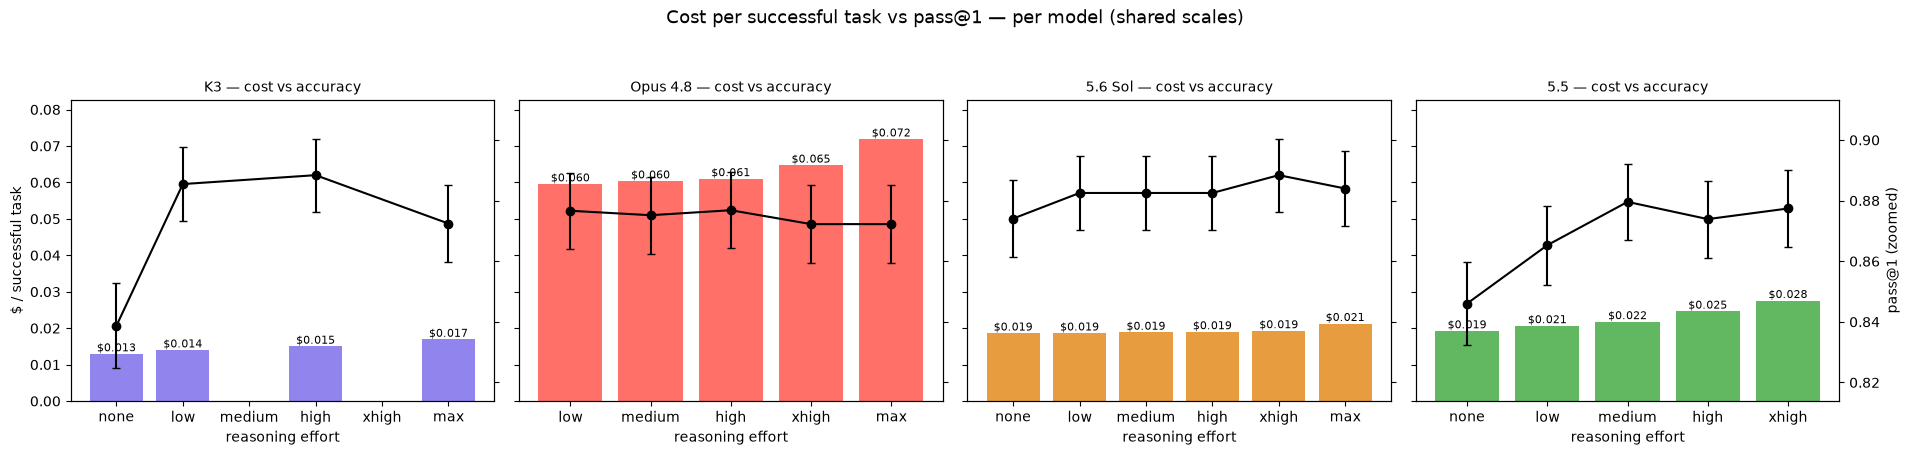

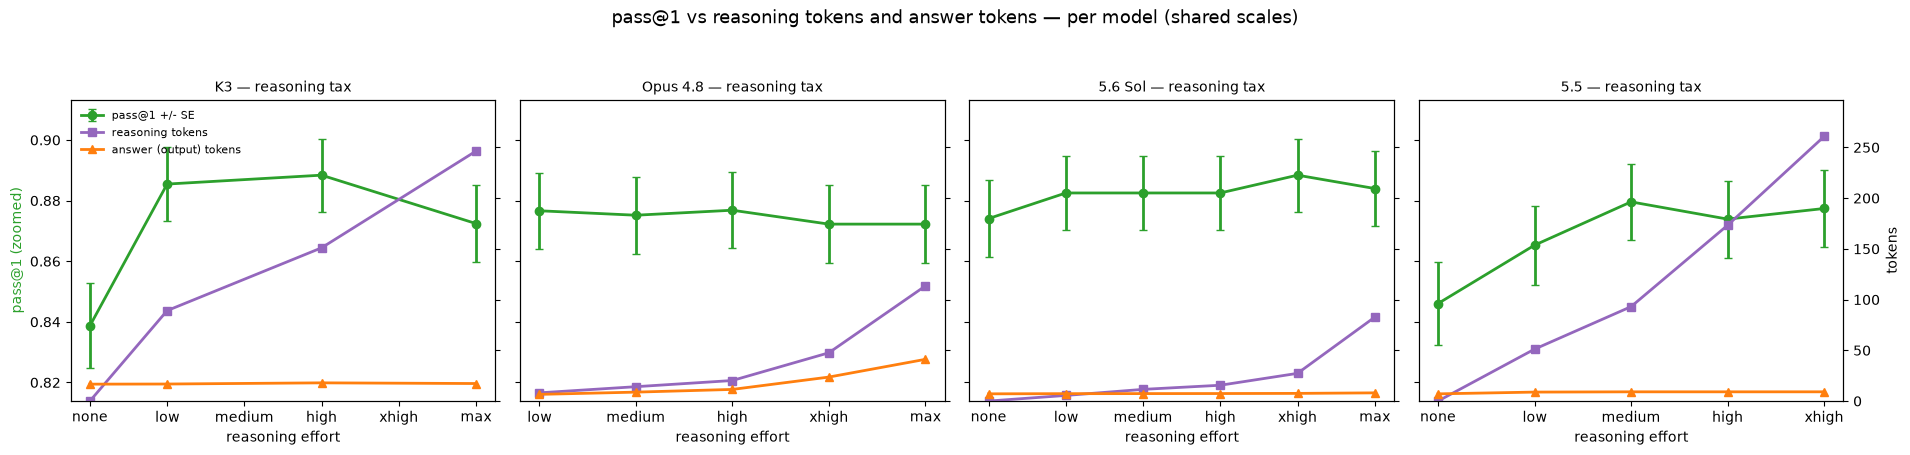

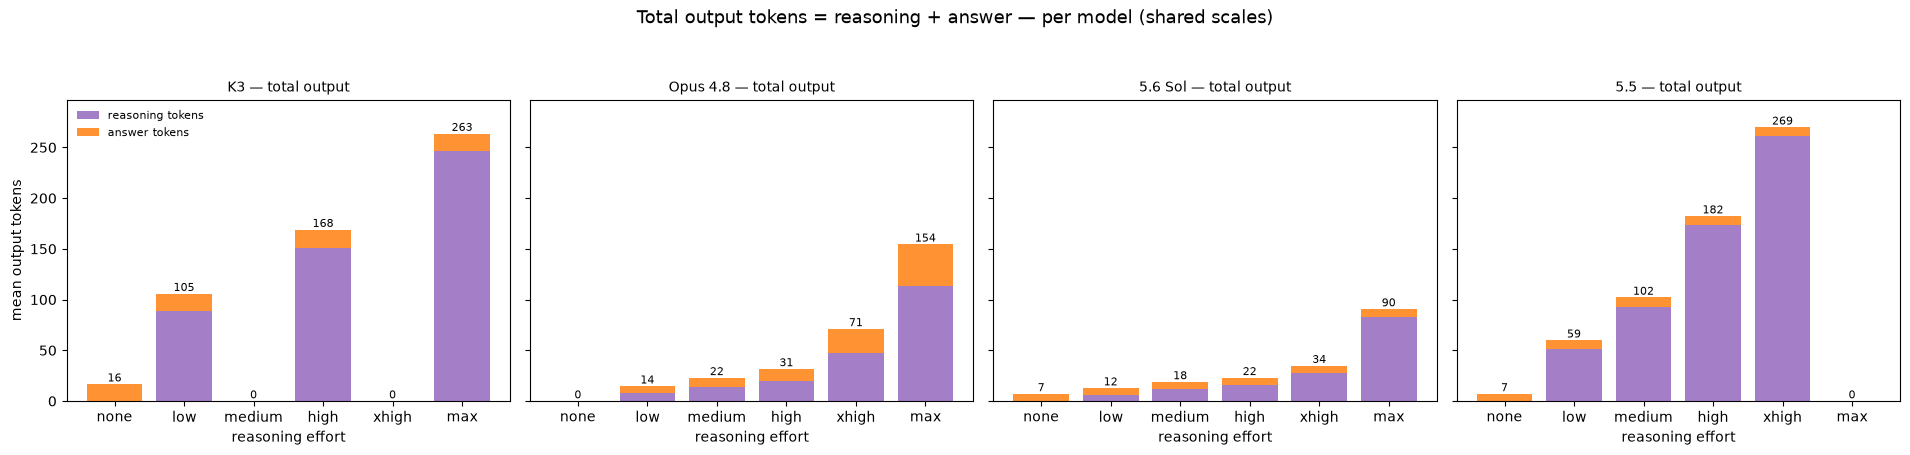

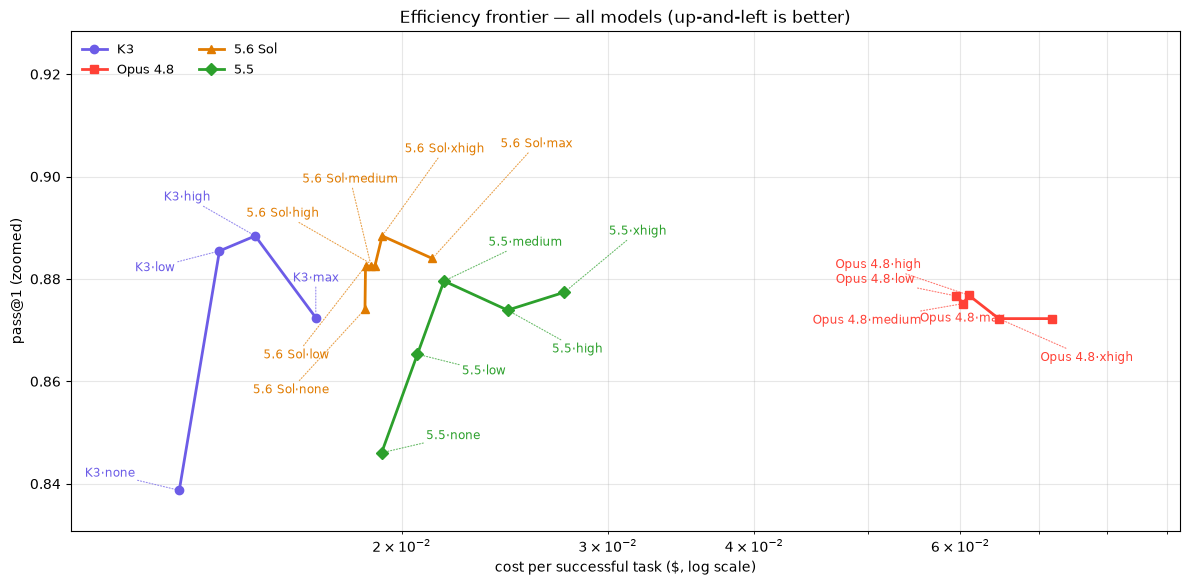

In [20]:
# Charts. reasoning effort on the x-axis; pass@1 barely moves as effort climbs.
# "accuracy" here == pass@1 (mean single-sample success over N_SAMPLES draws).
# Chart 1: cost/success vs pass@1. Chart 2: pass@1 vs reasoning tokens AND answer tokens
# (separately). Chart 2b: total output = reasoning + answer (stacked). Chart 3: frontier.
CANON = ["none", "low", "medium", "high", "xhigh", "max"]
PALETTE = ["#6C5CE7", "#FF4136", "#e07b00", "#2ca02c", "#2b6cb0"]
MARKERS = ["o", "s", "^", "D", "v"]

models = list(ACTIVE_MODELS)
COLOR = {m["label"]: PALETTE[i % len(PALETTE)] for i, m in enumerate(models)}
short_of = {m["label"]: m.get("short", "?") for m in models}
n = len(models)


def _acc_ylim(values):
    values = [v for v in values if v == v]
    if not values:
        return (0.0, 1.0)
    lo, hi = min(values), max(values)
    pad = max(0.02, (hi - lo) * 0.5)
    return max(0.0, lo - pad), min(1.0, hi + pad)


def _ladder(m):
    return [e for e in CANON if e in m["efforts"]]


XCATS = [e for e in CANON if any(e in m["efforts"] for m in models)]
ACC_YLIM = _acc_ylim(cell["accuracy"].tolist())
COST_YMAX = float(np.nanmax(cell["cost_per_success"])) * 1.15
RT_YMAX = float(np.nanmax(cell["reasoning_tokens"])) * 1.10
# Shared token y-max across the reasoning / answer / total token charts so panels compare.
TOK_YMAX = float(np.nanmax(cell["total_output_tokens"])) * 1.10
XPOS = {e: i for i, e in enumerate(XCATS)}


def _panel_df(model):
    return cell[cell["model"] == model["label"]].set_index("effort").reindex(XCATS).reset_index()


# Chart 1: cost per successful task (bars) + accuracy (line), one panel per model.
fig1, axes1 = plt.subplots(1, n, figsize=(4.8 * n, 4.6), squeeze=False, sharey=True)
for j, model in enumerate(models):
    sub = _panel_df(model)
    ax = axes1[0][j]
    c = COLOR[model["label"]]
    bars = ax.bar(sub["effort"], sub["cost_per_success"], color=c, alpha=0.75)
    ax.set_ylim(0, COST_YMAX)
    if j == 0:
        ax.set_ylabel("$ / successful task")
    ax.set_xlabel("reasoning effort")
    ax.set_title(f"{short_of[model['label']]} — cost vs accuracy", fontsize=10)
    for b, v in zip(bars, sub["cost_per_success"]):
        if np.isfinite(v):
            ax.annotate(f"${v:.3f}", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom", fontsize=8)
    axa = ax.twinx()
    _a = sub.dropna(subset=["accuracy"])
    axa.errorbar([XPOS[e] for e in _a["effort"]], _a["accuracy"], yerr=_a["acc_se"],
                 marker="o", color="black", lw=1.5, capsize=3)
    axa.set_ylim(*ACC_YLIM)
    axa.set_ylabel("pass@1 (zoomed)" if j == n - 1 else "")
    if j != n - 1:
        axa.set_yticklabels([])
fig1.suptitle("Cost per successful task vs pass@1 — per model (shared scales)", fontsize=13)
fig1.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Chart 2: pass@1 vs token spend, split into REASONING vs ANSWER (visible output) tokens.
# The story: reasoning tokens balloon with effort while the answer stays tiny and pass@1
# barely moves -> you pay for thinking you don't cash in.
fig2, axes2 = plt.subplots(1, n, figsize=(4.8 * n, 4.6), squeeze=False, sharey=True)
for j, model in enumerate(models):
    sub = _panel_df(model)
    ax = axes2[0][j]
    _a = sub.dropna(subset=["accuracy"])
    ax.errorbar([XPOS[e] for e in _a["effort"]], _a["accuracy"], yerr=_a["acc_se"],
                marker="o", color="tab:green", lw=2, capsize=3, label="pass@1 +/- SE")
    ax.set_xticks(range(len(XCATS)))
    ax.set_xticklabels(XCATS)
    ax.set_ylim(*ACC_YLIM)
    if j == 0:
        ax.set_ylabel("pass@1 (zoomed)", color="tab:green")
    ax.set_xlabel("reasoning effort")
    ax.set_title(f"{short_of[model['label']]} — reasoning tax", fontsize=10)
    axt = ax.twinx()
    _r = sub.dropna(subset=["reasoning_tokens"])
    axt.plot([XPOS[e] for e in _r["effort"]], _r["reasoning_tokens"], marker="s", color="tab:purple",
             lw=2, label="reasoning tokens")
    _o = sub.dropna(subset=["answer_tokens"])
    axt.plot([XPOS[e] for e in _o["effort"]], _o["answer_tokens"], marker="^", color="tab:orange",
             lw=2, label="answer (output) tokens")
    axt.set_ylim(0, TOK_YMAX)
    axt.set_ylabel("tokens" if j == n - 1 else "")
    if j != n - 1:
        axt.set_yticklabels([])
    if j == 0:
        la, laa = ax.get_legend_handles_labels()
        lt, ltt = axt.get_legend_handles_labels()
        ax.legend(la + lt, laa + ltt, fontsize=8, loc="upper left", frameon=False)
fig2.suptitle("pass@1 vs reasoning tokens and answer tokens — per model (shared scales)", fontsize=13)
fig2.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Chart 2b: total output = reasoning + answer, stacked per effort, one panel per model.
fig2b, axes2b = plt.subplots(1, n, figsize=(4.8 * n, 4.6), squeeze=False, sharey=True)
for j, model in enumerate(models):
    sub = _panel_df(model)
    ax = axes2b[0][j]
    xs = list(range(len(XCATS)))
    r_vals = [sub.loc[sub["effort"] == e, "reasoning_tokens"].sum() if e in set(sub["effort"]) else np.nan
              for e in XCATS]
    a_vals = [sub.loc[sub["effort"] == e, "answer_tokens"].sum() if e in set(sub["effort"]) else np.nan
              for e in XCATS]
    ax.bar(xs, r_vals, color="tab:purple", alpha=0.85, label="reasoning tokens")
    ax.bar(xs, a_vals, bottom=np.nan_to_num(r_vals), color="tab:orange", alpha=0.85, label="answer tokens")
    for xi, (rv, av) in enumerate(zip(r_vals, a_vals)):
        if np.isfinite(rv) and np.isfinite(av):
            ax.annotate(f"{int(rv + av)}", (xi, rv + av), ha="center", va="bottom", fontsize=8)
    ax.set_xticks(xs)
    ax.set_xticklabels(XCATS)
    ax.set_ylim(0, TOK_YMAX)
    ax.set_xlabel("reasoning effort")
    if j == 0:
        ax.set_ylabel("mean output tokens")
        ax.legend(fontsize=8, loc="upper left", frameon=False)
    ax.set_title(f"{short_of[model['label']]} — total output", fontsize=10)
fig2b.suptitle("Total output tokens = reasoning + answer — per model (shared scales)", fontsize=13)
fig2b.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Chart 3: efficiency frontier overlay across ALL models.
fig3, ax3 = plt.subplots(figsize=(12, 6.2))
PLACEMENT = {"K3": "left", "5.6 Sol": "above", "5.5": "right"}
fan = [12, -12, 28, -28, 44, -44, 60, -60]


def _label_offset(place, i, right, npts):
    if place == "left":
        return (-32, fan[i % len(fan)], "right", "center")
    if place == "right":
        return (32, fan[i % len(fan)], "left", "center")
    if place == "above":
        spread = 150.0
        dx = -spread / 2 + (spread * i / (npts - 1) if npts > 1 else 0.0)
        dy = 58 + (20 if i % 2 else 0)
        return (dx, dy, "center", "bottom")
    return ((30, fan[i % len(fan)], "left", "center") if right
            else (-30, fan[i % len(fan)], "right", "center"))


for mi, model in enumerate(models):
    lab, short = model["label"], short_of[model["label"]]
    c = COLOR[lab]
    mk = MARKERS[mi % len(MARKERS)]
    place = PLACEMENT.get(short, "auto")
    sub = (cell[cell["model"] == lab].set_index("effort").reindex(_ladder(model))
           .reset_index().dropna(subset=["cost_per_success"]))
    if sub.empty:
        continue
    ax3.plot(sub["cost_per_success"], sub["accuracy"], marker=mk, color=c, lw=2, label=short)
    median_cost = sub["cost_per_success"].median()
    npts = len(sub)
    for i, (_, r) in enumerate(sub.iterrows()):
        right = r["cost_per_success"] >= median_cost
        if short == "K3" and r["effort"] == "max":
            dx, dy, ha, va = (0, 24, "center", "bottom")
        elif short == "5.6 Sol" and r["effort"] in ("none", "low"):
            dx, dy, ha, va = (-26, (-58 if r["effort"] == "none" else -64), "right", "center")
        elif short == "5.6 Sol" and r["effort"] == "high":
            dx, dy, ha, va = (-40, 38, "right", "center")
        elif short == "Opus 4.8" and r["effort"] == "high":
            dx, dy, ha, va = (-34, 22, "right", "center")
        elif short == "Opus 4.8" and r["effort"] == "max":
            dx, dy, ha, va = (-34, 0, "right", "center")
        else:
            dx, dy, ha, va = _label_offset(place, i, right, npts)
        ax3.annotate(f"{short}·{r['effort']}", (r["cost_per_success"], r["accuracy"]),
                     textcoords="offset points", xytext=(dx, dy),
                     fontsize=8.5, color=c, ha=ha, va=va, annotation_clip=False,
                     arrowprops=dict(arrowstyle="-", linestyle=":", lw=0.8, color=c, alpha=0.7,
                                     shrinkA=0, shrinkB=3))
_acc_vals = [v for v in cell["accuracy"].tolist() if v == v]
ax3.set_ylim(min(_acc_vals) - 0.008, max(_acc_vals) + 0.04)
ax3.set_xlabel("cost per successful task ($, log scale)")
ax3.set_ylabel("pass@1 (zoomed)")
ax3.set_xscale("log")
xmin, xmax = ax3.get_xlim()
ax3.set_xlim(xmin * 0.88, xmax * 1.18)
ax3.grid(True, alpha=0.3, which="both")
ax3.set_title("Efficiency frontier — all models (up-and-left is better)", fontsize=12)
ax3.legend(fontsize=9, loc="upper left", frameon=False, ncol=2)
fig3.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

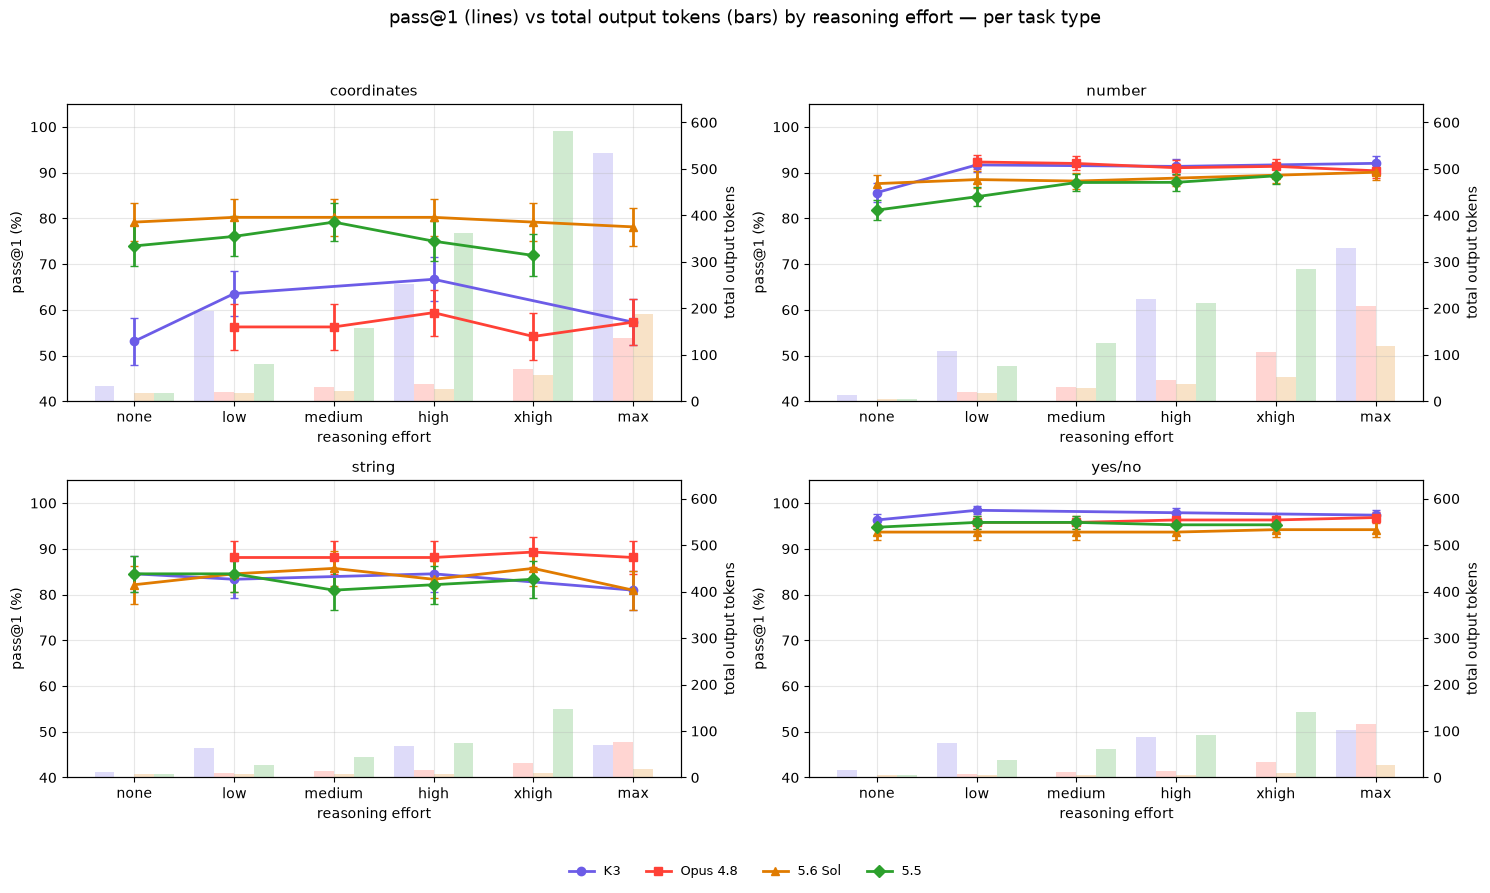

pass@1 (%) by model x effort x task type:


answer_type                         coordinates  number  string  yes/no
model                       effort                                     
Claude Opus 4.8 (Anthropic) high           59.4    91.1    88.1    96.3
                            low            56.2    92.3    88.1    95.8
                            max            57.3    90.4    88.1    96.8
                            medium         56.2    92.0    88.1    95.8
                            xhigh          54.2    91.3    89.3    96.3
GPT-5.5 (OpenAI)            high           75.0    87.9    82.1    95.2
                            low            76.0    84.7    84.5    95.8
                            medium         79.2    87.8    81.0    95.8
                            none           74.0    81.8    84.5    94.7
                            xhigh          71.9    89.3    83.3    95.2
GPT-5.6 Sol (OpenAI)        high           80.2    88.8    83.3    93.7
                            low            80.2    88.5    84.5    93.7
                            max            78.1    90.1    81.0    94.2
                            medium         80.2    88.1    85.7    93.7
                            none           79.2    87.6    82.1    93.7
                            xhigh          79.2    89.4    85.7    94.2
Kimi K3                     high           66.7    91.3    84.5    97.9
                            low            63.5    91.7    83.3    98.4
                            max            57.3    92.0    81.0    97.4
                            none           53.1    85.6    84.5    96.3

In [24]:
# Per task type: pass@1 vs reasoning effort, one line per model. One panel per answer_type.
# Shows whether cranking effort helps on each kind of task (counting, yes/no, string, coords).
from IPython.display import display

CANON = ["none", "low", "medium", "high", "xhigh", "max"]
TYPES = sorted(ok["answer_type"].unique())
model_labels = [m["label"] for m in ACTIVE_MODELS]
short_of = {m["label"]: m.get("short", "?") for m in ACTIVE_MODELS}
COLOR = {m["label"]: ["#6C5CE7", "#FF4136", "#e07b00", "#2ca02c", "#2b6cb0"][i % 5]
         for i, m in enumerate(ACTIVE_MODELS)}
MARKERS = {m["label"]: ["o", "s", "^", "D", "v"][i % 5] for i, m in enumerate(ACTIVE_MODELS)}

by_te = (
    ok.groupby(["model", "effort", "answer_type"])
    .agg(attempts=("score", "count"), pass_at_1=("score", "mean"),
         tot_tokens=("total_output_tokens", "mean"))
    .reset_index()
)
by_te["se"] = (by_te["pass_at_1"] * (1 - by_te["pass_at_1"]) / by_te["attempts"]).pow(0.5)

XCATS = [e for e in CANON if e in set(ok["effort"])]
XPOS = {e: i for i, e in enumerate(XCATS)}
TOK_MAX = float(by_te["tot_tokens"].max()) * 1.10  # shared token scale across panels
_nb = len(ACTIVE_MODELS)
_bw = 0.8 / max(_nb, 1)

ncols = min(2, len(TYPES))
nrows = (len(TYPES) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, 4.4 * nrows), squeeze=False)
axf = axes.ravel()
for j, t in enumerate(TYPES):
    ax = axf[j]
    axt = ax.twinx()  # secondary axis: total output tokens (bars, behind the pass@1 lines)
    for mi, m in enumerate(ACTIVE_MODELS):
        lab = m["label"]
        effs = [e for e in CANON if e in m["efforts"]]
        sub = (by_te[(by_te["model"] == lab) & (by_te["answer_type"] == t)]
               .set_index("effort").reindex(effs).dropna(subset=["tot_tokens"]).reset_index())
        if sub.empty:
            continue
        xb = [XPOS[e] - 0.4 + _bw * (mi + 0.5) for e in sub["effort"]]
        axt.bar(xb, sub["tot_tokens"], width=_bw, color=COLOR[lab], alpha=0.22, zorder=0)
    axt.set_ylim(0, TOK_MAX)
    axt.set_ylabel("total output tokens")
    for m in ACTIVE_MODELS:
        lab = m["label"]
        effs = [e for e in CANON if e in m["efforts"]]
        sub = (by_te[(by_te["model"] == lab) & (by_te["answer_type"] == t)]
               .set_index("effort").reindex(effs).dropna(subset=["pass_at_1"]).reset_index())
        if sub.empty:
            continue
        ax.errorbar([XPOS[e] for e in sub["effort"]], sub["pass_at_1"] * 100, yerr=sub["se"] * 100,
                    marker=MARKERS[lab], color=COLOR[lab], lw=2, capsize=3, label=short_of[lab])
    ax.set_zorder(axt.get_zorder() + 1)  # keep the pass@1 lines on top of the bars
    ax.patch.set_visible(False)
    ax.set_xticks(range(len(XCATS)))
    ax.set_xticklabels(XCATS)
    ax.set_ylim(40, 105)
    ax.set_xlabel("reasoning effort")
    ax.set_ylabel("pass@1 (%)")
    ax.set_title(t, fontsize=11)
    ax.grid(True, alpha=0.3)
for k in range(len(TYPES), len(axf)):
    axf[k].axis("off")

from matplotlib.lines import Line2D
_handles = [Line2D([0], [0], marker=MARKERS[m["label"]], color=COLOR[m["label"]], lw=2,
                   label=short_of[m["label"]]) for m in ACTIVE_MODELS]
fig.legend(handles=_handles, loc="lower center", ncol=len(_handles), fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("pass@1 (lines) vs total output tokens (bars) by reasoning effort — per task type", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.show()

print("pass@1 (%) by model x effort x task type:")
display((by_te.pivot_table(index=["model", "effort"], columns="answer_type", values="pass_at_1") * 100).round(1))